# Fine-tuning CheXNet with Synthetic Augmentation

Trains a binary pneumonia classifier starting from CheXNet pretrained weights.

**Strategy:** frozen DenseNet-121 backbone + trainable binary head (linear probe).
Synthetic `healthy_to_pneumonia` images from the **training split** are added as
extra pneumonia examples to address the severe class imbalance.

| Component | Details |
|---|---|
| Backbone | DenseNet-121 from CheXNet (all layers frozen) |
| Head | Linear 1024 → 1 (trainable only) |
| Training data | Original train set + synthetic H→P (train split only) |
| Input size | 224 × 224 (both original and synthetic) |

# Dataset

In [7]:
import pandas as pd

In [8]:
train_df = pd.read_csv("/Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/data/splits/train_split.csv")
eval_df = pd.read_csv("/Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/data/splits/val_split.csv")
test_df = pd.read_csv("/Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/data/splits/test_split.csv")

print(f"Size of train: {train_df.shape}")
print(f"Size of eval: {eval_df.shape}")
print(f"Size of test: {test_df.shape}")

Size of train: (43450, 14)
Size of eval: (9157, 14)
Size of test: (9176, 14)


## 0. Configuration

In [17]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "utils"))

# --- Paths ---
CHEXNET_CKPT    = PROJECT_ROOT / "models" / "Classifier" / "chexnet.pth.tar"

TRAIN_SPLIT_CSV = PROJECT_ROOT / "data" / "splits" / "train_split.csv"
H2P_DIR         = PROJECT_ROOT / "synthetic" / "cycleGAN" / "healthy_to_pneumonia"
RESULTS_DIR     = PROJECT_ROOT / "results" / "chexnet_finetune_synthetic"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = PROJECT_ROOT / "models" / "Classifier" / "chexnet_finetune_synthetic.pt"

# --- Hyperparameters ---
IMG_SIZE    = 224
BATCH_SIZE  = 64
LR          = 1e-3
NUM_EPOCHS  = 20
PATIENCE    = 5     # early stopping
SEED        = 42

import torch
torch.manual_seed(SEED)
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray


In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from PIL import Image

SPLITS_DIR    = PROJECT_ROOT / "data" / "splits"
HEALTHY_DIR   = PROJECT_ROOT / "data" / "healthy_images"
PNEUMONIA_DIR = PROJECT_ROOT / "data" / "pnemonia_images"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed_v2"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

from dataset import PyTorchDataset  # utils/ já no sys.path

ORIG_IMG_SIZE = (128, 128)  # mesmo padrão de create_cvae_dataset

def build_dataset_from_split(csv_path: Path, img_size=IMG_SIZE, verbose=True):
    df = pd.read_csv(csv_path)

    images = []
    valid_indices = []

    for i, row in df.iterrows():
        folder = PNEUMONIA_DIR if row["Label"] == 1 else HEALTHY_DIR
        img_path = folder / row["Image Index"]

        if img_path.exists():
            images.append(Image.open(img_path).resize(img_size))
            valid_indices.append(i)

    df_valid = df.loc[valid_indices].reset_index(drop=True)

    labels = torch.from_numpy(
        np.eye(2)[df_valid["Label"].astype(int).values]
    ).float()

    metadata = torch.from_numpy(
        np.column_stack([
            df_valid["Patient Age Normalized"].values,
            df_valid["Patient Gender Encoded"].values,
        ])
    ).float()

    if verbose:
        n_pos = int(df_valid["Label"].sum())
        n_neg = len(df_valid) - n_pos
        print(f"{csv_path.stem}: {len(images)} imagens  (pneumonia={n_pos}, healthy={n_neg})")

    return PyTorchDataset(images, labels, metadata)


In [11]:
train_dataset = build_dataset_from_split(SPLITS_DIR / "train_split.csv")
val_dataset   = build_dataset_from_split(SPLITS_DIR / "val_split.csv")
test_dataset  = build_dataset_from_split(SPLITS_DIR / "test_split.csv")

train_split: 42661 imagens  (pneumonia=225, healthy=42436)
val_split: 8993 imagens  (pneumonia=54, healthy=8939)
test_split: 9021 imagens  (pneumonia=43, healthy=8978)


In [12]:
for name, ds in [("train", train_dataset), ("val", val_dataset), ("test", test_dataset)]:
    img, label, meta = ds[0]
    print(f"[{name}]  n={len(ds)}")
    print(f"  image    shape={img.shape}   dtype={img.dtype}   min={img.min():.3f} max={img.max():.3f}")
    print(f"  labels   shape={ds.labels.shape}  dtype={ds.labels.dtype}  sample={label}")
    print(f"  metadata shape={ds.metadata.shape}  dtype={ds.metadata.dtype}  sample={meta}")
    n_pos = int(ds.labels[:, 1].sum())
    print(f"  pneumonia={n_pos}  healthy={len(ds)-n_pos}\n")

[train]  n=42661
  image    shape=torch.Size([1, 128, 128])   dtype=torch.float32   min=0.000 max=0.871
  labels   shape=torch.Size([42661, 2])  dtype=torch.float32  sample=tensor([0., 1.])
  metadata shape=torch.Size([42661, 2])  dtype=torch.float32  sample=tensor([0.8523, 1.0000])
  pneumonia=225  healthy=42436

[val]  n=8993
  image    shape=torch.Size([1, 128, 128])   dtype=torch.float32   min=0.000 max=0.953
  labels   shape=torch.Size([8993, 2])  dtype=torch.float32  sample=tensor([0., 1.])
  metadata shape=torch.Size([8993, 2])  dtype=torch.float32  sample=tensor([0.4773, 1.0000])
  pneumonia=54  healthy=8939

[test]  n=9021
  image    shape=torch.Size([1, 128, 128])   dtype=torch.float32   min=0.000 max=0.902
  labels   shape=torch.Size([9021, 2])  dtype=torch.float32  sample=tensor([0., 1.])
  metadata shape=torch.Size([9021, 2])  dtype=torch.float32  sample=tensor([0.3523, 1.0000])
  pneumonia=43  healthy=8978



In [ ]:
torch.save(train_dataset, PROCESSED_DIR / "train_dataset.pt")
torch.save(val_dataset,   PROCESSED_DIR / "val_dataset.pt")
torch.save(test_dataset,  PROCESSED_DIR / "test_dataset.pt")

print("Salvo em data/processed_v2/")

Salvo em data/processed/


## 1. Load model

In [15]:
from models.Classifier.classifier import CheXNetLinearProbe
from device import get_device

DEVICE = get_device()
model = CheXNetLinearProbe(CHEXNET_CKPT).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Device         : {DEVICE}")
print(f"Trainable params: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")

Device         : mps
Trainable params: 1,025 / 6,954,881  (0.0%)


## 2. Build augmented training dataset

- **Original training set** — loaded from `train_dataset.pt` (128×128, resized to 224)
- **Synthetic H→P images** — only those whose filename appears in `train_split.csv`
  (avoids leaking validation / test images into training)

In [19]:
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms

sys.path.insert(0, str(PROJECT_ROOT / "utils"))

resize_224 = transforms.Resize((IMG_SIZE, IMG_SIZE), antialias=True)
to_tensor  = transforms.ToTensor()

TRAIN_DS_PT     = PROJECT_ROOT / "data" / "processed_v2" / "train_dataset.pt"
VAL_DS_PT       = PROJECT_ROOT / "data" / "processed_v2" / "val_dataset.pt"
TEST_DS_PT      = PROJECT_ROOT / "data" / "processed_v2" / "test_dataset.pt"

class OriginalDataset(Dataset):
    """Wraps train_dataset.pt, resizes to 224×224, returns (img, binary_label)."""

    def __init__(self, pt_path: Path, augment: bool = False):
        self.ds = torch.load(pt_path, weights_only=False)
        self.augment = augment
        self.aug_tfm = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
        ]) if augment else None

    def __len__(self): return len(self.ds)

    def __getitem__(self, idx):
        img, label, _ = self.ds[idx]          # img: (1, 128, 128)
        img = resize_224(img)                  # (1, 224, 224)
        if self.augment and self.aug_tfm:
            img = self.aug_tfm(img)
        return img, label[1].unsqueeze(0).float()  # binary: (1,)


class SyntheticDataset(Dataset):
    """Loads synthetic H→P PNGs filtered to a given set of filenames."""

    def __init__(self, h2p_dir: Path, allowed_names: set[str], augment: bool = False):
        self.paths = [
            p for p in h2p_dir.glob("*.png") if p.name in allowed_names
        ]
        self.augment = augment
        self.aug_tfm = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
        ]) if augment else None

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = to_tensor(Image.open(self.paths[idx]).convert("L"))  # (1, H, W)
        img = resize_224(img)                                        # (1, 224, 224)
        if self.augment and self.aug_tfm:
            img = self.aug_tfm(img)
        return img, torch.ones(1)  # label = pneumonia


# Filter synthetic images to training split only
train_split_df   = pd.read_csv(TRAIN_SPLIT_CSV)
train_names      = set(train_split_df["Image Index"])
h2p_train_names  = {p.name for p in H2P_DIR.glob("*.png")} & train_names

train_orig  = OriginalDataset(TRAIN_DS_PT, augment=True)
train_synth = SyntheticDataset(H2P_DIR, h2p_train_names, augment=True)
train_ds    = ConcatDataset([train_orig, train_synth])

val_ds  = OriginalDataset(VAL_DS_PT,  augment=False)
test_ds = OriginalDataset(TEST_DS_PT, augment=False)

# Class counts for pos_weight
orig_labels   = torch.stack([train_orig[i][1] for i in range(len(train_orig))]).squeeze()
n_pos_orig    = orig_labels.sum().item()
n_neg_orig    = (1 - orig_labels).sum().item()
n_pos_total   = n_pos_orig + len(train_synth)   # synthetic images are all pneumonia
n_neg_total   = n_neg_orig
pos_weight    = torch.tensor([n_neg_total / n_pos_total])

print(f"Original train  : {len(train_orig):>7,}  (pneumonia: {int(n_pos_orig)}, healthy: {int(n_neg_orig)})")
print(f"Synthetic H→P   : {len(train_synth):>7,}  (all pneumonia)")
print(f"Combined train  : {len(train_ds):>7,}")
print(f"Val             : {len(val_ds):>7,}")
print(f"Test            : {len(test_ds):>7,}")
print(f"pos_weight      : {pos_weight.item():.2f}")

Original train  :  42,661  (pneumonia: 225, healthy: 42436)
Synthetic H→P   :  42,436  (all pneumonia)
Combined train  :  85,097
Val             :   8,993
Test            :   9,021
pos_weight      : 0.99


In [20]:
torch.save(train_ds, PROCESSED_DIR / "train_dataset_aug_cyclegan.pt")

print("Salvo em data/processed_v2/")

Salvo em data/processed_v2/


## 3. Train

In [21]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = Adam(model.classifier.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.1, patience=2)

In [22]:
history = {"train_loss": [], "val_loss": [], "val_auc": []}
best_val_auc = 0.0
patience_ctr = 0

epoch_bar = tqdm(range(1, NUM_EPOCHS + 1), desc="Training", unit="epoch")
for epoch in epoch_bar:
    # --- Train ---
    model.train()
    train_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [train]", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- Validate ---
    model.eval()
    val_loss, all_scores, all_labels = 0.0, [], []
    with torch.inference_mode():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            val_loss += criterion(logits, labels).item()
            all_scores.extend(torch.sigmoid(logits).cpu().squeeze().tolist())
            all_labels.extend(labels.cpu().squeeze().tolist())
    val_loss /= len(val_loader)
    val_auc = roc_auc_score(all_labels, all_scores)
    scheduler.step(val_auc)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_AUC={val_auc:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        patience_ctr = 0
        print(f"  → New best ({best_val_auc:.4f}) — checkpoint saved")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping after {epoch} epochs.")
            break

print(f"\nBest val AUC: {best_val_auc:.4f}")

Training:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epoch 1/20 [train]:   0%|          | 0/1330 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.5763 | val_loss=0.3532 | val_AUC=0.7028
  → New best (0.7028) — checkpoint saved


Epoch 2/20 [train]:   0%|          | 0/1330 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.5558 | val_loss=0.5230 | val_AUC=0.6801


...

Epoch 04 | train_loss=0.5426 | val_loss=0.3905 | val_AUC=0.6794


Epoch 5/20 [train]:   0%|          | 0/1330 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.5361 | val_loss=0.3931 | val_AUC=0.6795


Epoch 6/20 [train]:   0%|          | 0/1330 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.5341 | val_loss=0.3616 | val_AUC=0.6816
Early stopping after 6 epochs.

Best val AUC: 0.7028


## 4. Training curves

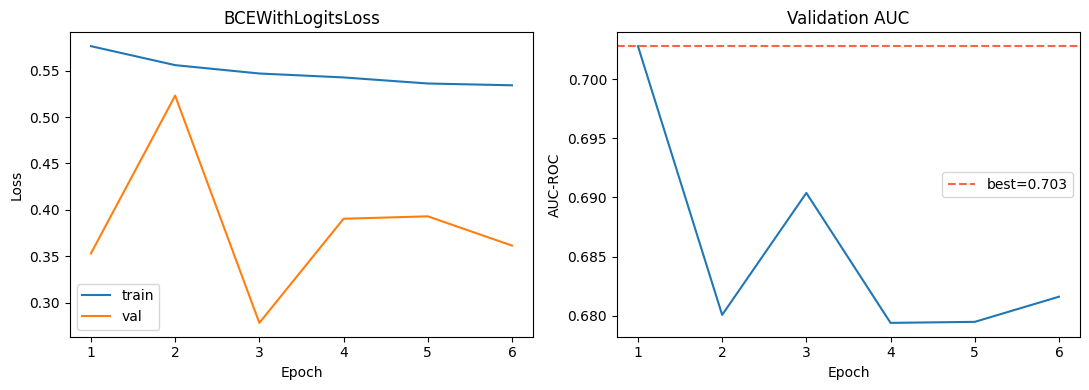

In [23]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"],   label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("BCEWithLogitsLoss"); axes[0].legend()

axes[1].plot(epochs, history["val_auc"])
axes[1].axhline(best_val_auc, linestyle="--", color="tomato", label=f"best={best_val_auc:.3f}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUC-ROC")
axes[1].set_title("Validation AUC"); axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=120)
plt.show()

## 5. Evaluate on test set

In [28]:
from sklearn.metrics import roc_curve

# Reload best checkpoint
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

# --- 1. inference on val set for best threshold ---
val_ds = torch.load(PROJECT_ROOT / "data" / "processed_v2" / "val_dataset.pt", weights_only=False)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0)

val_scores, val_labels = [], []
with torch.inference_mode():
    for imgs, labels, _ in val_loader:
        logits = model(imgs.to(DEVICE))
        val_scores.extend(torch.sigmoid(logits).cpu().squeeze().tolist())
        val_labels.extend(labels[:, 1].cpu().squeeze().tolist())  # one-hot → coluna pneumonia

val_sc = np.array(val_scores)
val_y  = np.array(val_labels)

# --- 2. Youden's J: maximize TPR - FPR ---
fpr, tpr, thresholds = roc_curve(val_y, val_sc)
best_idx       = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]

print(f"Best threshold (val): {best_threshold:.4f}")
print(f"  TPR={tpr[best_idx]:.3f}  FPR={fpr[best_idx]:.3f}")

Best threshold (val): 0.2504
  TPR=0.815  FPR=0.591


In [30]:
from metrics import compute_accuracy, compute_roc_auc, compute_confusion_matrix, print_metrics, plot_roc_curve

# Reload best checkpoint
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
all_scores, all_labels = [], []

with torch.inference_mode():
    for imgs, labels in test_loader:
        logits = model(imgs.to(DEVICE))
        all_scores.extend(torch.sigmoid(logits).cpu().squeeze().tolist())
        all_labels.extend(labels.squeeze().tolist())

y_scores = np.array(all_scores)
y_true   = np.array(all_labels)

print(f"Test set: {len(y_true)} images  |  pneumonia: {int(y_true.sum())}  |  healthy: {int((1-y_true).sum())}")

Test set: 9021 images  |  pneumonia: 43  |  healthy: 8978


=== CheXNet fine-tuned with synthetic augmentation ===
Accuracy : 0.5425
AUC-ROC  : 0.6863
Confusion matrix (threshold=0.2503763437271118):
  TN=4864  FP=4114
  FN=13  TP=30
ROC curve saved to results/chexnet_roc_curve.png


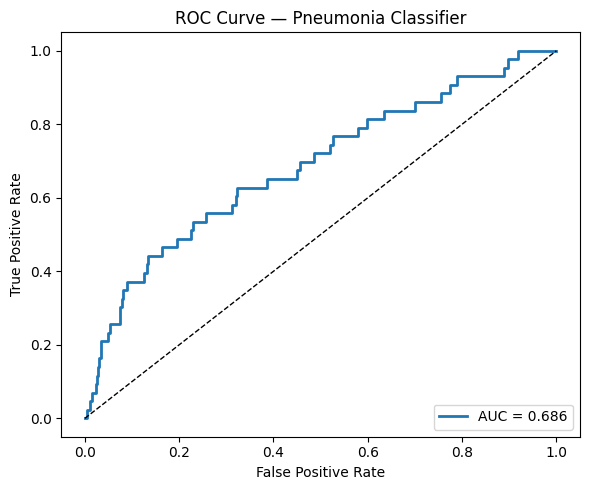

In [31]:
# --- 3. evaluate test set with best threshold ---
print("=== CheXNet fine-tuned with synthetic augmentation ===")
print_metrics(y_true, y_scores, threshold=best_threshold)
plot_roc_curve(y_true, y_scores, save_path=RESULTS_DIR / "chexnet_roc_curve_finetuning.png")
print("ROC curve saved to results/chexnet_roc_curve.png")

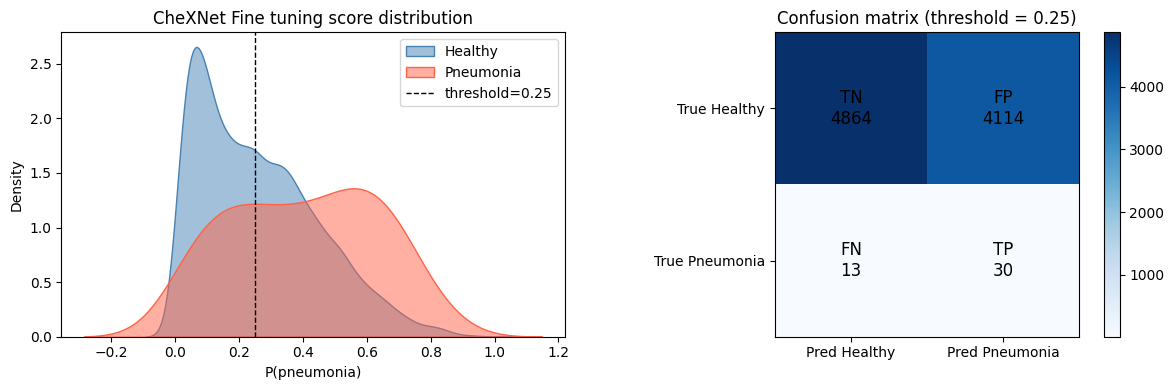

Saved to /Users/mabosco/Desktop/mestrado/IA376N/dgm-2026.1/projects/ecgpcx-ray/results/chexnet_finetune_synthetic/chexnet_ft_evaluation.png


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = compute_confusion_matrix(y_true, y_scores, threshold=best_threshold)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Score distribution ---
ax = axes[0]
sns.kdeplot(y_scores[y_true == 0], ax=ax, fill=True, common_norm=False,
            label="Healthy", color="steelblue", alpha=0.5)
sns.kdeplot(y_scores[y_true == 1], ax=ax, fill=True, common_norm=False,
            label="Pneumonia", color="tomato", alpha=0.5)
ax.axvline(best_threshold, color="black", linestyle="--", linewidth=1, label=f"threshold={best_threshold:.2f}")
ax.set_xlabel("P(pneumonia)")
ax.set_ylabel("Density")
ax.set_title("CheXNet Fine tuning score distribution")
ax.legend()

# --- Confusion matrix ---
ax = axes[1]
mat = [[tn, fp], [fn, tp]]
labels = [["TN", "FP"], ["FN", "TP"]]
im = ax.imshow(mat, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{mat[i][j]}", ha="center", va="center", fontsize=12)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred Healthy", "Pred Pneumonia"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["True Healthy", "True Pneumonia"])
ax.set_title(f"Confusion matrix (threshold = {best_threshold:.2f})")
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "chexnet_ft_evaluation.png", dpi=120)
plt.show()
print(f"Saved to {RESULTS_DIR}/chexnet_ft_evaluation.png")

## 6. Save results

In [33]:
import json

cm = compute_confusion_matrix(y_true, y_scores, threshold=0.5)
tn, fp, fn, tp = cm.ravel()

results = {
    "best_val_auc"   : round(best_val_auc, 4),
    "test_auc"       : round(float(compute_roc_auc(y_true, y_scores)), 4),
    "test_accuracy"  : round(float(compute_accuracy(y_true, y_scores)), 4),
    "confusion_matrix": {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)},
    "train_synthetic_n": len(train_synth),
    "train_original_n" : len(train_orig),
    "hyperparams": {
        "lr": LR, "batch_size": BATCH_SIZE,
        "epochs_trained": len(history["train_loss"]),
        "pos_weight": round(pos_weight.item(), 2),
    },
}

with open(RESULTS_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

{
  "best_val_auc": 0.7028,
  "test_auc": 0.6863,
  "test_accuracy": 0.8753,
  "confusion_matrix": {
    "TN": 7880,
    "FP": 1098,
    "FN": 27,
    "TP": 16
  },
  "train_synthetic_n": 42436,
  "train_original_n": 42661,
  "hyperparams": {
    "lr": 0.001,
    "batch_size": 64,
    "epochs_trained": 6,
    "pos_weight": 0.99
  }
}
